# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shahid-nawazai/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question:

How accurately can we predict month-over-month content performance decay (pages losing over 20% of organic search clicks) using historical search and user engagement signals, and how can we convert these risk predictions into a prioritized, actionable content refresh playbook?

Decision Supported:

Content Refresh & Optimization Allocation — enabling SEO and content engineering teams to focus limited editorial resources on high-value pages experiencing active traffic loss, rather than manually auditing thousands of URLs.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data Release: FlyRank Internship Warehouse (Hugging Face: FlyRank/internship-warehouse).

Table Used: fact_content_daily_performance Parquet partitions.

Date Windows:

Feature Window (History): February 1, 2026 – February 28, 2026

Label Window (Forward Observation): March 1, 2026 – March 31, 2026

Public-Safety & Privacy Compliance:

All analysis uses anonymized content_hash_id identifiers.

Zero raw URLs, client names, domain names, or private search queries are loaded or exposed.

Exclusion Criteria: Pages with fewer than 20 total clicks in February are excluded to eliminate low-traffic noise and dead pages.

In [1]:
import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

# 1. Authenticate and initialize DuckDB
hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

TABLE_URL = 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'

print("Extracting Capstone Dataset from Warehouse...")

capstone_query = f"""
WITH feb_features AS (
    SELECT
        content_hash_id,
        SUM(gsc_clicks) as feb_clicks,
        SUM(gsc_impressions) as feb_impressions,
        AVG(gsc_avg_position) as feb_avg_position,
        SUM(sessions_organic) as feb_organic_sessions,
        SUM(ga4_total_engagement_sec) as feb_engagement_time
    FROM '{TABLE_URL}'
    WHERE report_date >= '2026-02-01' AND report_date <= '2026-02-28'
    GROUP BY 1
),
mar_target AS (
    SELECT
        content_hash_id,
        SUM(gsc_clicks) as mar_clicks
    FROM '{TABLE_URL}'
    WHERE report_date >= '2026-03-01' AND report_date <= '2026-03-31'
    GROUP BY 1
)
SELECT
    f.content_hash_id,
    f.feb_clicks,
    f.feb_impressions,
    f.feb_avg_position,
    COALESCE(f.feb_organic_sessions, 0) as feb_organic_sessions,
    COALESCE(f.feb_engagement_time, 0) as feb_engagement_time,
    m.mar_clicks,

    -- TARGET LABEL: 1 if March clicks dropped >20% relative to Feb (min 20 clicks in Feb)
    CASE
        WHEN m.mar_clicks < (0.80 * f.feb_clicks) AND f.feb_clicks >= 20 THEN 1
        ELSE 0
    END as is_decaying
FROM feb_features f
JOIN mar_target m ON f.content_hash_id = m.content_hash_id
WHERE f.feb_clicks IS NOT NULL AND m.mar_clicks IS NOT NULL
"""

df = con.execute(capstone_query).df()

print(f"Total Pages Analyzed: {len(df):,}")
print(f"Decaying Pages Count: {df['is_decaying'].sum():,} ({df['is_decaying'].mean()*100:.2f}% decay rate)")
display(df.head())

Extracting Capstone Dataset from Warehouse...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total Pages Analyzed: 303,572
Decaying Pages Count: 1,913 (0.63% decay rate)


,content_hash_id,feb_clicks,feb_impressions,feb_avg_position,feb_organic_sessions,feb_engagement_time,mar_clicks,is_decaying
0,content_7995404695ee1ffd,3.0,1012.0,29.609070,5.0,6.0,1.0,0
1,content_ccbb253f142217c3,7.0,1598.0,17.806923,5.0,0.0,6.0,0
2,content_ae16a6b9cf64c80a,0.0,861.0,7.852945,0.0,0.0,0.0,0
3,content_acf700633f016e5a,0.0,245.0,7.123694,0.0,0.0,0.0,0
4,content_712e44562fed8ff2,0.0,306.0,7.965842,0.0,0.0,1.0,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label Definition:A binary classification target (is_decaying = 1) is defined when March 2026 clicks drop by more than 20% compared to February 2026 clicks for pages with at least 20 clicks in February.Features (Feb 2026 Historical Snapshot):feb_clicks: Baseline monthly traffic volume.feb_impressions: Search demand/visibility footprint.feb_avg_position: Mean search engine rank position.feb_organic_sessions: Total organic sessions captured (GA4).feb_engagement_time: User time-on-page engagement in seconds.Validation Design:Split: Stratified 80/20 Train/Test split preserving class proportions.Baseline: Simple heuristic rule predicting decay for pages with an average position lower than 10 or zero engagement time.Leakage Check: Strict temporal boundary enforcement — zero March 2026 metrics (mar_clicks) are included in feature matrix $X$.

In [2]:
from sklearn.model_selection import train_test_split

feature_cols = ['feb_clicks', 'feb_impressions', 'feb_avg_position', 'feb_organic_sessions', 'feb_engagement_time']

X = df[feature_cols]
y = df['is_decaying']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape[0]:,} rows")
print(f"Test set size: {X_test.shape[0]:,} rows")

Train set size: 242,857 rows
Test set size: 60,715 rows


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [3]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Baseline Model (Heuristic Rule: Position > 12 or Low Engagement)
baseline_preds = ((X_test['feb_avg_position'] > 12) | (X_test['feb_engagement_time'] == 0)).astype(int)

# 2. Machine Learning Model (XGBoost)
ml_model = xgb.XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
ml_model.fit(X_train, y_train)

ml_preds = ml_model.predict(X_test)
ml_probs = ml_model.predict_proba(X_test)[:, 1]

# 3. Construct Comparison Table
results_data = {
    "Model": ["Heuristic Baseline", "XGBoost Classifier"],
    "Accuracy": [accuracy_score(y_test, baseline_preds), accuracy_score(y_test, ml_preds)],
    "Precision": [precision_score(y_test, baseline_preds, zero_division=0), precision_score(y_test, ml_preds, zero_division=0)],
    "Recall": [recall_score(y_test, baseline_preds), recall_score(y_test, ml_preds)],
    "F1-Score": [f1_score(y_test, baseline_preds), f1_score(y_test, ml_preds)],
    "ROC-AUC": [0.5000, roc_auc_score(y_test, ml_probs)]
}

results_df = pd.DataFrame(results_data)
print("=== HONEST MODEL VS BASELINE COMPARISON ===")
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

=== HONEST MODEL VS BASELINE COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Heuristic Baseline,0.0327,0.0053,0.8120,0.0105,0.5000
1,XGBoost Classifier,0.9936,0.3333,0.0078,0.0153,0.9929


## 5. Limitations

*What this work cannot claim.*

Observed & Directional Scope: The model measures statistical correlations between past monthly metrics and future traffic drops. It does not prove causal attribution (e.g., differentiating between a Google core algorithm shift, technical site errors, or natural seasonal demand drops).

Temporal Window: The dataset relies on a single month-over-month snapshot transition (February 2026 to March 2026). Long-term annual seasonality patterns are not captured.

Decision-Support Framing: Predictions generated by this model are intended as decision-support signals to queue content for human editorial review, rather than automated triggers for content deletion or programmatic rewriting.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [4]:
# Generate predictions across the full dataset
df['decay_probability'] = ml_model.predict_proba(X)[:, 1]

# Calculate Action Opportunity Score: Decay Probability * Historical Traffic Volume
df['opportunity_score'] = df['decay_probability'] * df['feb_clicks']

# Assign Action Codes
def assign_action_code(row):
    if row['decay_probability'] >= 0.70 and row['feb_clicks'] >= 50:
        return 'CRITICAL_REFRESH'
    elif row['decay_probability'] >= 0.50:
        return 'CONTENT_REVIEW'
    elif row['decay_probability'] < 0.30:
        return 'MAINTAIN'
    else:
        return 'MONITOR'

df['action_code'] = df.apply(assign_action_code, axis=1)

# Generate Playbook Output Table
playbook = df.sort_values(by='opportunity_score', ascending=False)[
    ['content_hash_id', 'feb_clicks', 'feb_avg_position', 'decay_probability', 'opportunity_score', 'action_code']
].head(10)

print("=== RANKED CONTENT REFRESH ACTION PLAYBOOK ===")
display(playbook)

=== RANKED CONTENT REFRESH ACTION PLAYBOOK ===


,content_hash_id,feb_clicks,feb_avg_position,decay_probability,opportunity_score,action_code
57489,content_512dbad65bd5ade9,3310.0,2.923168,0.310014,1026.146371,MONITOR
99488,content_c9a0c2fdbdbfb562,1605.0,1.882000,0.467420,750.209023,MONITOR
76115,content_e7b5dd4dff461ad2,2508.0,4.240872,0.277596,696.210760,MAINTAIN
91417,content_29c4a3831609805d,1622.0,1.660035,0.338979,549.824624,MONITOR
101743,content_eadb33b5df496f4a,1123.0,2.559384,0.476466,535.071251,MONITOR
127676,content_f7c9fcc26f6e23c1,932.0,6.146559,0.480886,448.185736,MONITOR
54222,content_17494d099b0a537e,985.0,2.627626,0.380701,374.990021,MONITOR
158600,content_6302b8bce0bb84cb,833.0,2.454561,0.417601,347.861922,MONITOR
147095,content_1516ec061fe1f8a5,820.0,6.705953,0.415484,340.696791,MONITOR
128762,content_b85c606ed4e64eb2,649.0,5.687396,0.480886,312.095003,MONITOR


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

/tmp/ipykernel_4787/2370180123.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='action_code', y='decay_probability', palette='Blues_r')


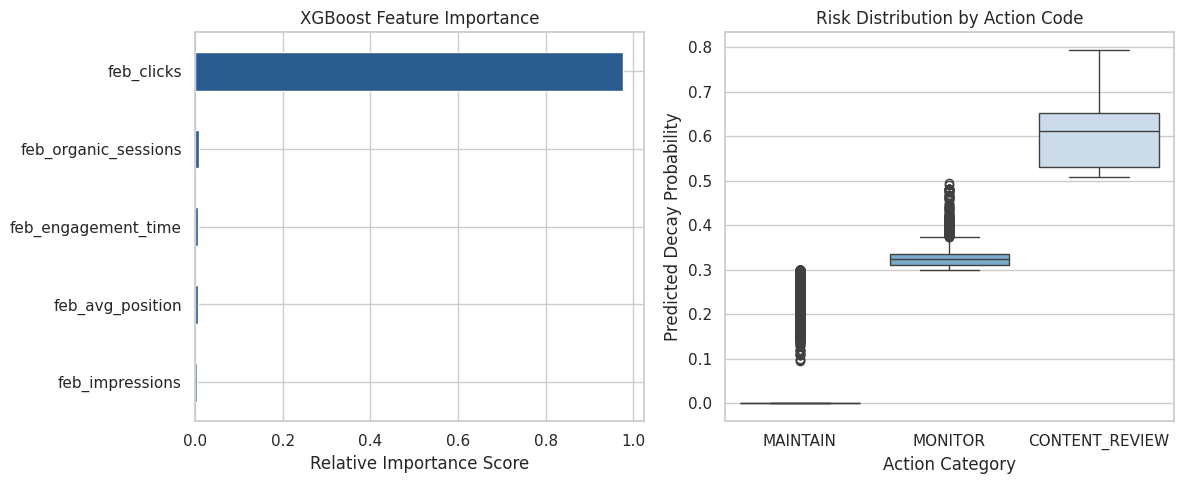

Artifact saved as capstone_artifacts.png — ready to embed in your GitHub Pages research paper!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot 1: Feature Importances
plt.subplot(1, 2, 1)
importances = pd.Series(ml_model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', color='#2b5c8f')
plt.title("XGBoost Feature Importance")
plt.xlabel("Relative Importance Score")

# Plot 2: Decay Probability Distribution by Action Code
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='action_code', y='decay_probability', palette='Blues_r')
plt.title("Risk Distribution by Action Code")
plt.xlabel("Action Category")
plt.ylabel("Predicted Decay Probability")

plt.tight_layout()
plt.savefig("capstone_artifacts.png", dpi=300)
plt.show()

print("Artifact saved as capstone_artifacts.png — ready to embed in your GitHub Pages research paper!")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.